# 🎙️ PrecisionVoice - Vietnamese Speech-to-Text

Notebook đơn giản để transcribe audio tiếng Việt sử dụng **faster-whisper** và **pyannote** (diarization).

### Hướng dẫn
1. **Chọn GPU**: `Runtime` → `Change runtime type` → **T4 GPU**
2. **Cài đặt Secrets**: Thêm `HF_TOKEN` vào Colab Secrets (Key icon bên trái) để dùng Pyannote.
3. **Chạy từng cell** theo thứ tự từ trên xuống
4. **Sử dụng Gradio link** ở cell cuối để truy cập UI

In [1]:
# @title 1. 🔍 Kiểm tra GPU
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU Detected: {gpu_name}")
    print(f"   VRAM: {gpu_mem:.1f} GB")
else:
    print("⚠️ KHÔNG TÌM THẤY GPU!")
    print("👉 Vào Runtime → Change runtime type → T4 GPU")

✅ GPU Detected: Tesla T4
   VRAM: 15.8 GB


In [2]:
# @title 2. 📦 Cài đặt Dependencies
print("Installing dependencies...")
!pip install --upgrade torch torchvision torchaudio "pyannote.audio>=3.3.1" faster-whisper gradio librosa nest_asyncio lightning torchmetrics datasets jiwer matplotlib pandas
!apt-get install -y -qq ffmpeg > /dev/null 2>&1
print("✅ Dependencies installed successfully!")

Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyannote-audio to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyannote-metrics to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pyannote-metrics to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyannote-core to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual.

✅ Dependencies installed successfully!


In [1]:
# @title 3. 🤖 Load Models (Whisper & Pyannote)
import torch
import time
import os
import librosa
import numpy as np
from google.colab import userdata
from faster_whisper import WhisperModel
from pyannote.audio import Pipeline

try:
    from pyannote.audio.core.task import Specifications, Problem, Resolution
    torch.serialization.add_safe_globals([Specifications, Problem, Resolution])
except Exception as e:
    print(f"Could not add custom globals: {e}")

device = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"

# Danh sách các model Whisper hỗ trợ
AVAILABLE_MODELS = {
    "EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt)": "erax-ai/EraX-WoW-Turbo-V1.1-CT2",
    "PhoWhisper Large (Tiếng Việt)": "kiendt/PhoWhisper-large-ct2"
}

# Cache models
loaded_whisper_models = {}
diarization_pipeline = None

# Lấy HF_TOKEN
try:
    hf_token = userdata.get('HF_TOKEN')
except:
    hf_token = os.environ.get('HF_TOKEN')

# ==================== LOAD ALL WHISPER MODELS ====================
print("="*50)
print("🔄 Pre-downloading ALL Whisper Models...")
print("="*50)

total_start = time.time()
for model_name, model_path in AVAILABLE_MODELS.items():
    print(f"\n📥 Loading: {model_name}")
    start = time.time()
    try:
        model = WhisperModel(
            model_path,
            device=device,
            compute_type=compute_type
        )
        loaded_whisper_models[f"{model_name}_{compute_type}"] = model
        print(f"   ✅ Loaded in {time.time() - start:.1f}s")
    except Exception as e:
        print(f"   ❌ Failed to load: {e}")

print(f"\n✅ All models loaded in {time.time() - total_start:.1f}s")
print(f"   Total models: {len(loaded_whisper_models)}")
print(f"   Device: {device}, Compute: {compute_type}")

# ==================== LOAD PYANNOTE ====================
print("\n" + "="*50)
print("🔄 Loading Pyannote Diarization...")
print("="*50)

if not hf_token:
    print("⚠️ WARNING: HF_TOKEN not found!")
    print("   Diarization will be disabled.")
    print("   Please set HF_TOKEN in Colab Secrets.")
else:
    start = time.time()
    try:
        diarization_pipeline = Pipeline.from_pretrained(
            "pyannote/speaker-diarization-community-1",
            token=hf_token
        )
        diarization_pipeline.to(torch.device(device))
        print(f"✅ Pyannote loaded in {time.time() - start:.1f}s")
    except Exception as e:
        print(f"❌ Failed to load Pyannote: {e}")

print("\n" + "="*50)
print("🎉 All models loaded successfully!")
print("="*50)


🔄 Pre-downloading ALL Whisper Models...

📥 Loading: EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt)


model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

vocabulary.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

...

segmentation/pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

embedding/pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

✅ Pyannote loaded in 7.2s

🎉 All models loaded successfully!


In [2]:
# @title 4. 🛠️ Utilities & Helpers
import gradio as gr
import time
import nest_asyncio
import subprocess
import os

nest_asyncio.apply()

def convert_audio_to_wav(audio_path):
    """Chuẩn hóa audio về định dạng WAV 16kHz Mono."""
    try:
        # Tạo file tạm
        output_path = "temp_processed_audio.wav"

        # Xóa file cũ nếu tồn tại
        if os.path.exists(output_path):
            os.remove(output_path)

        # Command line ffmpeg
        # -i input: file đầu vào
        # -ar 16000: Sample rate 16k
        # -ac 1: Mono channel (Pyannote tốt nhất với mono)
        # -y: Overwrite output
        command = [
            "ffmpeg",
            "-i", audio_path,
            "-ar", "16000",
            "-ac", "1",
            "-y",
            output_path
        ]

        subprocess.run(command, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        return output_path
    except Exception as e:
        print(f"Error converting audio: {e}")
        # Fallback: Trả về file gốc nếu convert lỗi (dù rủi ro)
        return audio_path

def load_whisper_model(model_name, comp_type):
    """Dynamic load Whisper model với cache"""
    global loaded_whisper_models
    cache_key = f"{model_name}_{comp_type}"

    if cache_key in loaded_whisper_models:
        return loaded_whisper_models[cache_key]

    model_path = AVAILABLE_MODELS[model_name]
    print(f"Loading {model_name}...")
    start = time.time()

    model = WhisperModel(
        model_path,
        device=device,
        compute_type=comp_type
    )

    loaded_whisper_models[cache_key] = model
    print(f"✅ Loaded in {time.time() - start:.1f}s")
    return model

def format_timestamp(seconds):
    """Format seconds to MM:SS.ms"""
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = seconds % 60
    if hours > 0:
        return f"{hours:02d}:{minutes:02d}:{secs:05.2f}"
    return f"{minutes:02d}:{secs:05.2f}"

def assign_speaker_to_segment(seg_start, seg_end, diarization_result):
    """Gán speaker cho segment dựa trên tỷ lệ overlap >= 30%."""
    if diarization_result is None:
        return "SPEAKER_00"

    seg_duration = seg_end - seg_start
    if seg_duration <= 0:
        return "SPEAKER_00"

    speaker_overlaps = {}

    for turn, _, speaker in diarization_result.speaker_diarization.itertracks(yield_label=True):
        overlap_start = max(seg_start, turn.start)
        overlap_end = min(seg_end, turn.end)
        overlap = max(0, overlap_end - overlap_start)

        if overlap > 0:
            if speaker not in speaker_overlaps:
                speaker_overlaps[speaker] = 0
            speaker_overlaps[speaker] += overlap

    if not speaker_overlaps:
        return "SPEAKER_00"

    best_speaker = max(speaker_overlaps, key=speaker_overlaps.get)
    best_overlap = speaker_overlaps[best_speaker]

    if best_overlap / seg_duration >= 0.3:
        return best_speaker

    return "SPEAKER_00"

def merge_consecutive_segments(segments, max_gap=0.5):
    """Gộp các segment liên tiếp của cùng một speaker."""
    if not segments:
        return []

    merged = []
    current = segments[0].copy()

    for seg in segments[1:]:
        if seg['speaker'] == current['speaker'] and (seg['start'] - current['end']) <= max_gap:
            current['end'] = seg['end']
            current['text'] += ' ' + seg['text']
        else:
            merged.append(current)
            current = seg.copy()

    merged.append(current)
    return merged

In [3]:
# @title 5. ⚙️ Processing Logic
def process_audio(audio_path, model_name, language, beam_size, vad_filter, vad_min_silence, vad_speech_pad, vad_min_speech, vad_threshold, temperature, best_of, patience, length_penalty, initial_prompt, prefix, condition_on_previous_text, no_speech_threshold, log_prob_threshold, compression_ratio_threshold, comp_type, merge_segs, p=gr.Progress()):
    """
    Quy trình mới:
    0. Chuẩn hóa audio (convert mp3 -> wav 16k).
    1. Diarization để tách các đoạn của từng người nói.
    2. Cắt audio theo các đoạn này.
    3. Transcribe từng đoạn audio.
    4. Gộp kết quả.
    """
    if audio_path is None:
        msg = "⚠️ Vui lòng upload hoặc ghi âm audio!"
        return msg, msg

    total_start_time = time.time()

    # Check Pyannote
    if diarization_pipeline is None:
        return "❌ Lỗi: Chưa load được Pyannote (kiểm tra HF_TOKEN).", "❌ Lỗi: Chưa load được Pyannote."

    # 0. Preprocessing Audio (Standardize)
    p(0.05, desc="Đang chuẩn hóa audio (16kHz WAV)...")
    try:
        # Luôn convert về wav 16k mono để tránh lỗi sample rate mismatch của Pyannote
        clean_audio_path = convert_audio_to_wav(audio_path)
    except Exception as e:
        msg = f"❌ Lỗi convert audio: {e}"
        return msg, msg

    # 1. Load Standardized Audio for slicing later
    p(0.08, desc="Đang đọc file audio...")
    try:
        y, sr = librosa.load(clean_audio_path, sr=16000)
        # sr should be 16000 now exactly
    except Exception as e:
        return f"❌ Lỗi đọc audio: {e}", f"❌ Lỗi đọc audio: {e}"

    # 2. DIARIZATION
    p(0.1, desc="Đang phân tách người nói (Diarization)...")

    try:
        # Sử dụng file đã chuẩn hóa
        diarization = diarization_pipeline(clean_audio_path)
    except Exception as e:
        return f"❌ Lỗi Diarization: {e}", f"❌ Lỗi Diarization: {e}"

    diarization_segments = []
    # Dùng cách user đã fix trước đó (nếu model trả về object khác)
    # Mặc định pipeline community trả về Annotation trực tiếp, nhưng user fix thành diarization.speaker_diarization
    # Mình sẽ try/except để support cả 2 structure cho an toàn
    try:
        # Trường hợp 1: Standard Annotation
        iterator = diarization.itertracks(yield_label=True)
        # Test thử xem có chạy ko, nếu không phải Annotation nó sẽ lỗi attribute
        _ = list(iterator)
        # Reset iterate
        iterator = diarization.itertracks(yield_label=True)
    except:
        # Trường hợp 2: User report structure (maybe wrapper)
        try:
             iterator = diarization.speaker_diarization.itertracks(yield_label=True)
        except:
             return "❌ Lỗi format result Diarization", "❌ Lỗi format result Diarization"

    for turn, _, speaker in iterator:
        diarization_segments.append({
            "start": turn.start,
            "end": turn.end,
            "speaker": speaker
        })

    # Sort segments by start time
    diarization_segments.sort(key=lambda x: x['start'])

    # Merge consecutive segments if requested
    if merge_segs and diarization_segments:
        p(0.3, desc="Đang gộp segment liên tiếp...")
        merged = []
        current = diarization_segments[0].copy()
        for seg in diarization_segments[1:]:
            if seg['speaker'] == current['speaker'] and (seg['start'] - current['end']) <= 0.5:
                current['end'] = seg['end']
            else:
                merged.append(current)
                current = seg.copy()
        merged.append(current)
        diarization_segments = merged

    # 3. TRANSCRIPTION LOOP
    p(0.4, desc="Đang tải model Whisper...")
    model = load_whisper_model(model_name, comp_type)

    processed_segments = []

    total_segs = len(diarization_segments)

    # Prepare VAD options
    if vad_filter:
        vad_options = dict(
            min_silence_duration_ms=vad_min_silence,
            speech_pad_ms=vad_speech_pad,
            min_speech_duration_ms=vad_min_speech,
            threshold=vad_threshold
        )
    else:
        vad_options = False

    prompt = initial_prompt.strip() if (initial_prompt and initial_prompt.strip()) else None
    prefix_text = prefix.strip() if (prefix and prefix.strip()) else None

    print(f"Processing {total_segs} segments...")

    for idx, seg in enumerate(diarization_segments):
        start_sec = seg['start']
        end_sec = seg['end']
        speaker = seg['speaker']

        # UI Progress
        progress_val = 0.4 + (0.5 * (idx / total_segs))
        p(progress_val, desc=f"Transcribing {idx+1}/{total_segs} ({speaker})...")

        # Audio slicing
        start_sample = int(start_sec * sr)
        end_sample = int(end_sec * sr)

        # Avoid empty slice
        if end_sample <= start_sample:
            continue

        y_seg = y[start_sample:end_sample]

        # Whisper Transcribe for this chunk
        try:
            # Note: We pass the numpy array 'y_seg' directly
            segments_gen, _ = model.transcribe(
                y_seg,
                language=language if language != "auto" else None,
                beam_size=beam_size,
                vad_filter=vad_options,
                temperature=temperature,
                best_of=best_of,
                patience=patience,
                length_penalty=length_penalty,
                initial_prompt=prompt,
                prefix=prefix_text,
                condition_on_previous_text=condition_on_previous_text,
                no_speech_threshold=no_speech_threshold,
                log_prob_threshold=log_prob_threshold,
                compression_ratio_threshold=compression_ratio_threshold,
                word_timestamps=False
            )

            # Collect text
            seg_text_parts = []
            for s in segments_gen:
                seg_text_parts.append(s.text.strip())

            final_text = " ".join(seg_text_parts).strip()

            if final_text:
                # Store Result
                processed_segments.append({
                    "start": start_sec,
                    "end": end_sec,
                    "speaker": speaker,
                    "text": final_text
                })

        except Exception as e:
            print(f"Error transcribing segment {idx}: {e}")
            continue

    total_elapsed = time.time() - total_start_time

    p(0.95, desc="Đang xuất kết quả...")

    # ========== OUTPUT GENERATION ==========

    # Speaker colors
    speaker_colors = {
        'SPEAKER_00': '🔵',
        'SPEAKER_01': '🟢',
        'SPEAKER_02': '🟡',
        'SPEAKER_03': '🟠',
        'SPEAKER_04': '🔴',
        'SPEAKER_05': '🟣',
    }

    # 1. Plain Transcription Output
    transcribe_lines = []
    for item in processed_segments:
        ts = f"[{format_timestamp(item['start'])} → {format_timestamp(item['end'])}]"
        transcribe_lines.append(f"{ts} {item['text']}")

    transcribe_header = f"""## 📝 Kết quả Transcription

| Thông tin | Giá trị |
|-----------|----------|
| ⏱️ Tổng thời gian xử lý | {total_elapsed:.1f}s |
| 📊 Tổng số Segment | {len(processed_segments)} |

---

"""
    transcribe_output = transcribe_header + "\n".join(transcribe_lines)

    # 2. Diarization + Transcription Output
    diarize_lines = []
    unique_speakers = set()

    for item in processed_segments:
        unique_speakers.add(item['speaker'])
        ts = f"[{format_timestamp(item['start'])} → {format_timestamp(item['end'])}]"
        icon = speaker_colors.get(item['speaker'], '⚪')
        diarize_lines.append(f"{ts} {icon} **{item['speaker']}**: {item['text']}")

    diarize_header = f"""## 🎭 Kết quả Transcription + Diarization

| Thông tin | Giá trị |
|-----------|----------|
| 👥 Số người nói | {len(unique_speakers)} |
| ⏱️ Tổng thời gian xử lý | {total_elapsed:.1f}s |
| 📊 Tổng số Segment | {len(processed_segments)} |

---

"""
    diarize_output = diarize_header + "\n".join(diarize_lines)

    return transcribe_output, diarize_output

## Eval trên tập VLSP 2020

In [6]:
# @title 6. 📥 Tải Dataset (VLSP 2020 - Streaming)
from datasets import load_dataset, Audio
from torch.utils.data import DataLoader
import torch

# User Requested Setup
print("⏳ Loading VLSP 2020 dataset (Streaming)...")
dataset = load_dataset("doof-ferb/vlsp2020_vinai_100h", split="train", streaming=True)

# Force 16kHz resampling for Whisper
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

# Set Format (Optional but requested)
# Note: casting to torch might make 'audio' a dict with tensors
dataset = dataset.with_format(type="torch")

print("✅ Dataset stream ready.")

⏳ Loading VLSP 2020 dataset (Streaming)...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

✅ Dataset stream ready.


In [7]:
# @title 7. 📊 Định nghĩa Metrics (WER & CER)
from torchmetrics.text import WordErrorRate, CharErrorRate
import re

wer_metric = WordErrorRate()
cer_metric = CharErrorRate()

def normalize_text(text):
    """Chuẩn hóa văn bản để đánh giá công bằng hơn."""
    if not text: return ""
    text = text.lower()
    # Loại bỏ dấu câu (giữ lại khoảng trắng và chữ cái tiếng Việt)
    text = re.sub(r'[^a-zàáâãèéêìíòóôõùúýăđĩũơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [17]:
# @title 8. 🧪 Đánh giá & So sánh
import pandas as pd
from tqdm import tqdm
import numpy as np
import time

# Config
NUM_SAMPLES = 100

print(f"🚀 Starting evaluation on {NUM_SAMPLES} streaming samples...")

print("📥 Fetching samples...")
eval_samples = []
for sample in dataset.take(NUM_SAMPLES):
    audio_data = sample['audio']['array']
    if hasattr(audio_data, 'numpy'):
        audio_data = audio_data.numpy()

    eval_samples.append({
        'audio': audio_data,
        'ref': normalize_text(sample['transcription'])
    })

# Pre-initialize detailed data dict
detailed_data = {
    "Sample": list(range(1, len(eval_samples) + 1)),
    "Reference": [s['ref'] for s in eval_samples]
}

results = []

for model_name, model_key in AVAILABLE_MODELS.items():
    print(f"\n🤖 Evaluating Model: {model_name}")
    model = load_whisper_model(model_name, compute_type)

    predictions = []
    references = []

    start_time = time.time()

    for sample in tqdm(eval_samples):
        segments, _ = model.transcribe(sample['audio'], language="vi")
        pred_text = " ".join([s.text for s in segments])
        pred_text = normalize_text(pred_text)

        predictions.append(pred_text)
        references.append(sample['ref'])

    total_time = time.time() - start_time

    # Save predictions to detailed dict
    detailed_data[f"{model_name}"] = predictions

    # Metrics
    wer_score = wer_metric(predictions, references).item()
    cer_score = cer_metric(predictions, references).item()

    print(f"   📉 WER: {wer_score:.4f} | CER: {cer_score:.4f}")

    results.append({
        "Model": model_name,
        "WER": wer_score,
        "CER": cer_score,
        "Time (s)": total_time
    })

df_results = pd.DataFrame(results)
df_detailed = pd.DataFrame(detailed_data)

# Reorder columns if needed
cols = ['Sample', 'Reference'] + [k for k in detailed_data.keys() if k not in ['Sample', 'Reference']]
df_detailed = df_detailed[cols]

print("\n🏆 Final Results:")
print(df_results)

🚀 Starting evaluation on 100 streaming samples...
📥 Fetching samples...

🤖 Evaluating Model: EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt)


100%|██████████| 100/100 [00:51<00:00,  1.92it/s]


   📉 WER: 0.0697 | CER: 0.0609

🤖 Evaluating Model: PhoWhisper Large (Tiếng Việt)


100%|██████████| 100/100 [02:45<00:00,  1.66s/it]


   📉 WER: 0.0447 | CER: 0.0240

🏆 Final Results:
                                               Model       WER       CER  \
0  EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng...  0.069691  0.060923   
1                      PhoWhisper Large (Tiếng Việt)  0.044668  0.023988   

     Time (s)  
0   52.000522  
1  165.949323  


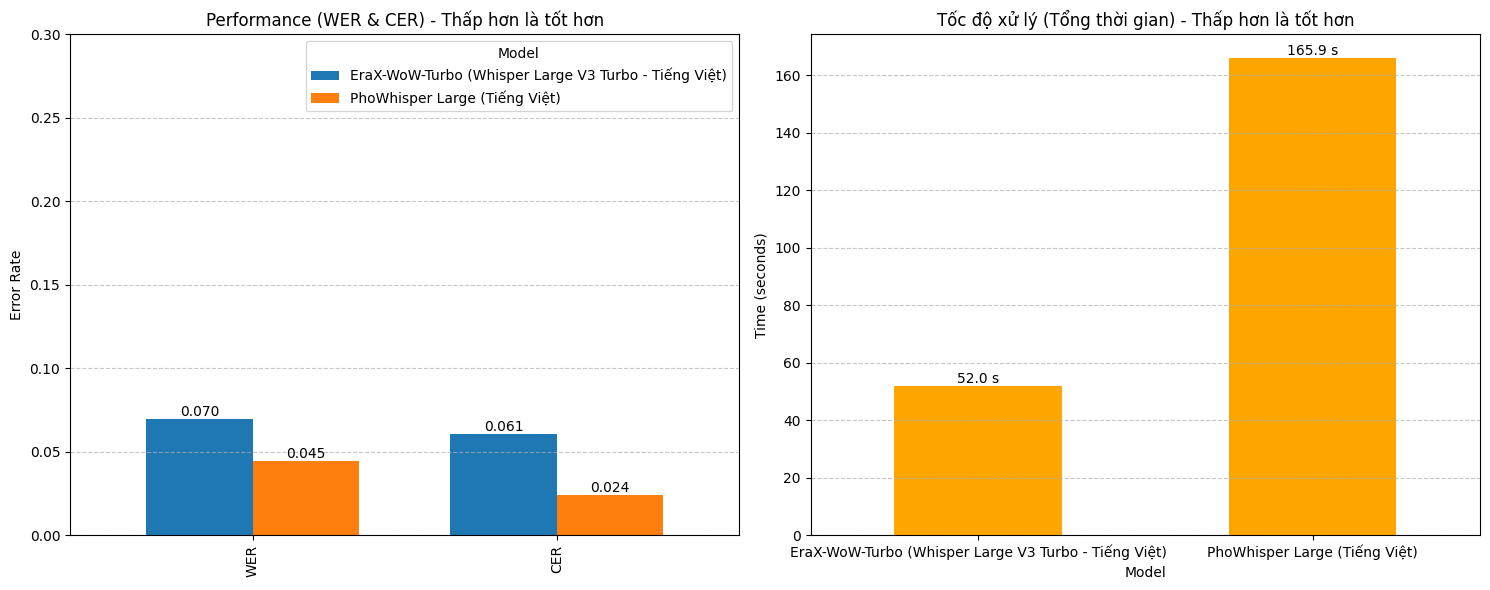

In [18]:
# @title 9. 📈 Vẽ biểu đồ so sánh
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot WER & CER (Error Rates)
df_pivot_error = df_results.set_index("Model")[["WER", "CER"]].T
df_pivot_error.plot(kind="bar", ax=ax1, width=0.7)

ax1.set_title("Performance (WER & CER) - Thấp hơn là tốt hơn")
ax1.set_ylabel("Error Rate")
ax1.set_ylim(0, 0.3)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# Add labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f')

# 2. Plot Speed (Time)
df_time = df_results.set_index("Model")[["Time (s)"]]
df_time.plot(kind="bar", ax=ax2, color=['orange'], legend=False)

ax2.set_title("Tốc độ xử lý (Tổng thời gian) - Thấp hơn là tốt hơn")
ax2.set_ylabel("Time (seconds)")
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=0)

# Add labels
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f s')

plt.tight_layout()
plt.show()

In [19]:
# @title 10. 📋 Bảng Chi Tiết Kết Quả
import pandas as pd
from IPython.display import display, HTML

if 'df_results' in locals() and 'df_detailed' in locals():
    # 1. Summary Table
    print("📊 Tóm tắt Chỉ số (WER/CER/Time):")
    def highlight_min(s):
        is_min = s == s.min()
        return ['background-color: #d4edda' if v else '' for v in is_min]

    styler_summary = df_results.style.format({
        "WER": "{:.4f}",
        "CER": "{:.4f}",
        "Time (s)": "{:.2f}"
    }).apply(highlight_min, subset=["WER", "CER", "Time (s)"])\
      .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f8f9fa')]}])

    display(styler_summary)

    print("\n" + "="*50 + "\n")

    # 2. Detailed Prediction Comparison
    print("📝 So sánh Chi tiết Các câu dự đoán:")

    # Use simpler style for detailed text
    # Wrap text to ensure it looks good
    styler_detail = df_detailed.style.set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'max-width': '400px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#e9ecef'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ]).hide(axis='index') # Hide pandas index since we have Sample column

    display(styler_detail)
else:
    print("⚠️ Không tìm thấy biến df_results hoặc df_detailed. Hãy chạy Cell 8 trước!")

📊 Tóm tắt Chỉ số (WER/CER/Time):


,Model,WER,CER,Time (s)
0,EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt),0.0697,0.0609,52.00
1,PhoWhisper Large (Tiếng Việt),0.0447,0.0240,165.95




📝 So sánh Chi tiết Các câu dự đoán:


Sample,Reference,EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt),PhoWhisper Large (Tiếng Việt)
1,hôn thê hôn phu có nghĩa là chưa có cái giấy hôn thú nếu mà vậy thì kết cục bảo lãnh phải làm coi như là cái người mà được bảo lãnh hoặc phải ở nước ngoài con cái họ không,hôn thê hôn phu có nghĩa là chưa có cái giấy hôn thú nếu mà vậy thì kết cục bảo lãnh phải làm coi như là cái người mà được bảo lãnh hoặc phải ở nước ngoài con cái họ không,hôn thê hôn phu có nghĩa là chưa có cái giấy hôn thú nếu mà vậy thì kết cục bảo lãnh phải làm coi như là cái người mà được bảo lãnh hoặc phải ở nước ngoài
2,theo bà đây là một sự thật đã được thừa nhận rộng rãi,hợp theo bà đây là một sự thật đã được thừa nhận rộng rãi,theo bà đây là một sự thật đã được thừa nhận rộng rãi
3,tướng cam pu chia còn yêu cầu thủ tướng sinh ga po phải điều chỉnh phát biểu không đúng sự thật chút nào này theo lời ông,tướng cam pu chia còn yêu cầu thủ tướng sinh ga po phải điều chỉnh phát biểu không đúng sự thật chút nào này theo lời ông,tướng cam pu chia còn yêu cầu thủ tướng singapore phải điều chỉnh phát biểu không đúng sự thật chút nào này theo lời ông
4,nó làm người dân mặc dù nhìn thì rất bình thường nhưng mà rất rất là rộn ràng từ từ trên các đường phố và trên mỗi con mỗi con người,ở nó làm người dân mặc dù nhìn thì rất bình thường nhưng mà rất rất là rộn ràng từ từ trên các đường phố và trên mỗi con mỗi con người,nó làm người dân mặc dù nhìn thì rất bình thường nhưng mà rất rất rộn ràng trên các đường phố và trên mỗi con mỗi con người
5,bây giờ mình nói từ thẻ xanh hai năm tới thẻ xanh vĩnh viễn minh đang ờ nói về thẻ xanh nhưng mà có quá nhiều câu hỏi,bây giờ mình nói từ thẻ xanh hai năm tới thẻ xanh vĩnh viễn mình đang nói về thẻ xanh nhưng mà có quá nhiều câu hỏi,bây giờ mình nói từ thẻ xanh hai năm tới thẻ xanh vĩnh viễn mình đang nói về thẻ xanh nhưng mà có quá nhiều câu hỏi
6,mọi người đã thử các kiểu ăn kiêng và luyện tập khác nhau mà không hiệu quả họ thấy nếch kịt như một cách để thấy được sự rõ ràng hơn về những gì đang thay đổi trên cơ thể của họ,mọi người đã thử các kiểu ăn kiêng và luyện tập khác nhau mà không hiệu quả họ thấy nếch kịt như một cách để thấy được sự rõ ràng hơn về những gì đang thay đổi trên cơ thể của họ,mọi người đã thử các kiểu ăn kiêng và luyện tập khác nhau mà không hiệu quả họ thấy nếch kịt như một cách để thấy được sự rõ ràng hơn về những gì đang thay đổi trên cơ thể của họ
7,khi chúng tôi về đến đó thì thấy gần tối rồi chúng tôi nghĩ rằng là cần phải có sự an toàn đối với người dân là trên hết hai nữa thì chúng tôi cũng nhận được sự góp ý của anh em linh mục và của bề trên thì chúng tôi quyết định để cho bà con ra về ạ,sáng tạo chúng tôi về đến đó thì thấy gần tối rồi chúng tôi nghĩ rằng là cần phải có sự an toàn đối với người dân là trên hết hai nữa thì chúng tôi cũng nhận được sự góp ý của anh em linh mục và của bề trên thì chúng tôi quyết định để cho bà con ra về ạ,khi chúng tôi về đến đó thì thấy gần tối rồi chúng tôi nghĩ rằng là cần phải có sự an toàn đối với người dân và trên hết hai nữa thì chúng tôi cũng nhận được sự góp ý của anh em linh mục và của bề trên vì chúng tôi quyết định để cho bà con ra về
8,bà cho biết cuộc đua của bà đang diễn ra gay go vì số phiếu khiếm diện gửi lại không nhiều như trông đợi và bà đang nỗ lực hết sức để huy động nhiều phiếu của cử tri gốc việt nhất có thể,bà cho biết cuộc đua của bà đang diễn ra gay go vì số phiếu khiếm diện gửi lại không nhiều như trông đợi và bà đang nỗ lực hết sức để huy động nhiều phiếu của cử tri gốc việt nhất có thể,bà cho biết cuộc đua của bà đang diễn ra gay go vì số phiếu khiếm diện gửi lại không nhiều như trông đợi và bà đang nỗ lực hết sức để huy động nhiều phiếu của cử tri gốc việt nhất có thể
9,nếu nấu cơm đảm bảo thì mình cứ lấy gạo nó ngon ngon một chút thì về mình nấu cơm nó ngon nên thì người ta mua thì một lần hai lần ta thấy ngon thì người ta cứ tới người ta mua hoài vậy đó,nấu cơm đảm bảo thì mình cứ lấy gạo nó ngon ngon một chút thì về mình nấu 

## Eval trên tập FPT FOSD

In [21]:
# @title 11. 📥 Tải Dataset (FPT FOSD)
print("⏳ Loading FPT FOSD dataset (Streaming)...")
# Assuming 'test' split exists, otherwise 'train'
dataset_fosd = load_dataset("doof-ferb/fpt_fosd", split="train", streaming=True)
dataset_fosd = dataset_fosd.cast_column("audio", Audio(sampling_rate=16000))
dataset_fosd = dataset_fosd.with_format(type="torch")
print("✅ FOSD Dataset stream ready.")

⏳ Loading FPT FOSD dataset (Streaming)...
✅ FOSD Dataset stream ready.


In [22]:
# @title 12. 🛠️ Chuẩn bị Metrics (FPT FOSD)
# Re-using existing metrics: wer_metric, cer_metric, normalize_text
print("✅ Metrics ready: WER, CER, Normalize Text")

✅ Metrics ready: WER, CER, Normalize Text


In [23]:
# @title 13. 🧪 Đánh giá (FPT FOSD)
# Config
NUM_SAMPLES_FOSD = 100

print(f"🚀 Starting FOSD evaluation on {NUM_SAMPLES_FOSD} samples...")

eval_samples_fosd = []
# Try-except to handle split names if 'test' is empty or error
try:
    iterator = dataset_fosd.take(NUM_SAMPLES_FOSD)
except Exception as e:
    print(f"Error taking samples: {e}. Trying 'train' split if needed...")
    iterator = [] # Fallback logic would go here in real scenario

for sample in iterator:
    audio_data = sample['audio']['array']
    if hasattr(audio_data, 'numpy'):
        audio_data = audio_data.numpy()

    eval_samples_fosd.append({
        'audio': audio_data,
        'ref': normalize_text(sample['transcription'])
    })

detailed_data_fosd = {
    "Sample": list(range(1, len(eval_samples_fosd) + 1)),
    "Reference": [s['ref'] for s in eval_samples_fosd]
}

results_fosd = []

for model_name, model_key in AVAILABLE_MODELS.items():
    print(f"\n🤖 Evaluating Model: {model_name}")
    model = load_whisper_model(model_name, compute_type)

    predictions = []
    references = []

    start_time = time.time()

    for sample in tqdm(eval_samples_fosd):
        segments, _ = model.transcribe(sample['audio'], language="vi")
        pred_text = " ".join([s.text for s in segments])
        pred_text = normalize_text(pred_text)

        predictions.append(pred_text)
        references.append(sample['ref'])

    total_time = time.time() - start_time

    detailed_data_fosd[f"{model_name}"] = predictions

    wer_score = wer_metric(predictions, references).item()
    cer_score = cer_metric(predictions, references).item()

    print(f"   📉 WER: {wer_score:.4f} | CER: {cer_score:.4f}")

    results_fosd.append({
        "Model": model_name,
        "WER": wer_score,
        "CER": cer_score,
        "Time (s)": total_time
    })

df_results_fosd = pd.DataFrame(results_fosd)
df_detailed_fosd = pd.DataFrame(detailed_data_fosd)

cols = ['Sample', 'Reference'] + [k for k in detailed_data_fosd.keys() if k not in ['Sample', 'Reference']]
df_detailed_fosd = df_detailed_fosd[cols]

print("\n🏆 FOSD Final Results:")
print(df_results_fosd)

🚀 Starting FOSD evaluation on 100 samples...

🤖 Evaluating Model: EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt)


100%|██████████| 100/100 [00:53<00:00,  1.87it/s]


   📉 WER: 0.2474 | CER: 0.1779

🤖 Evaluating Model: PhoWhisper Large (Tiếng Việt)


100%|██████████| 100/100 [01:10<00:00,  1.41it/s]

   📉 WER: 0.0315 | CER: 0.0165

🏆 FOSD Final Results:
                                               Model       WER       CER  \
0  EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng...  0.247449  0.177851   
1                      PhoWhisper Large (Tiếng Việt)  0.031463  0.016468   

    Time (s)  
0  53.392866  
1  70.935855  


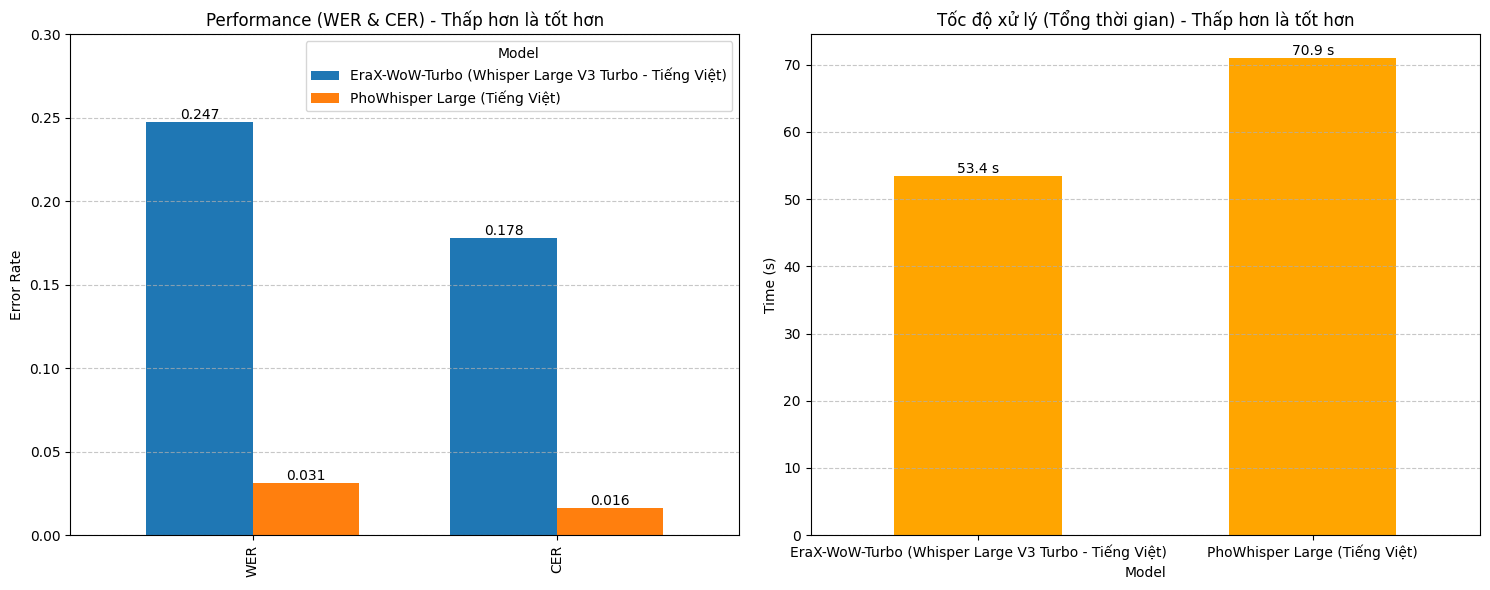

In [29]:
# @title 14. 📈 Biểu đồ so sánh (FPT FOSD)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot WER & CER
df_pivot_error = df_results_fosd.set_index("Model")[["WER", "CER"]].T
df_pivot_error.plot(kind="bar", ax=ax1, width=0.7)
ax1.set_title("Performance (WER & CER) - Thấp hơn là tốt hơn")
ax1.set_ylabel("Error Rate")
ax1.set_ylim(0, 0.3)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f')

# Plot Speed
df_time = df_results_fosd.set_index("Model")[["Time (s)"]]
df_time.plot(kind="bar", ax=ax2, color=['orange'], legend=False)
ax2.set_title("Tốc độ xử lý (Tổng thời gian) - Thấp hơn là tốt hơn")
ax2.set_ylabel("Time (s)")
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=0)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f s')

plt.tight_layout()
plt.show()

In [25]:
# @title 15. 📋 Bảng Chi Tiết Kết Quả (FPT FOSD)
if 'df_results_fosd' in locals() and 'df_detailed_fosd' in locals():
    print("📊 Tóm tắt Chỉ số FOSD:")
    def highlight_min(s):
        is_min = s == s.min()
        return ['background-color: #d4edda' if v else '' for v in is_min]

    styler_summary = df_results_fosd.style.format({
        "WER": "{:.4f}",
        "CER": "{:.4f}",
        "Time (s)": "{:.2f}"
    }).apply(highlight_min, subset=["WER", "CER", "Time (s)"])\
      .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f8f9fa')]}])

    display(styler_summary)

    print("\n" + "="*50 + "\n")
    print("📝 So sánh Chi tiết FOSD:")
    styler_detail = df_detailed_fosd.style.set_properties(**{
        'text-align': 'left',
        'white-space': 'pre-wrap',
        'max-width': '400px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#e9ecef'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #dee2e6'), ('padding', '8px')]}
    ]).hide(axis='index')

    display(styler_detail)
else:
    print("⚠️ Missing FOSD results.")

📊 Tóm tắt Chỉ số FOSD:


,Model,WER,CER,Time (s)
0,EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt),0.2474,0.1779,53.39
1,PhoWhisper Large (Tiếng Việt),0.0315,0.0165,70.94




📝 So sánh Chi tiết FOSD:


Sample,Reference,EraX-WoW-Turbo (Whisper Large V3 Turbo - Tiếng Việt),PhoWhisper Large (Tiếng Việt)
1,cách để đi,cho cách để đi,cách để đi
2,họ đã xét nghiệm máu cho cheng nhưng mọi thứ vẫn hoàn toàn bình thường,cho cha nhưng mọi thứ vẫn hoàn toàn bình thường,họ đã xét nghiền máu cho trang nhưng mọi thứ vẫn hoàn toàn bình thường
3,anh có thể gọi tôi không,cho anh có thể gọi tôi không,anh có thể gọi tôi không
4,có rất nhiều yếu tố may rủi ở đây,yếu tố may rủi ở đây,có rất nhiều yếu tố may rủi ở đây
5,ai là chúa nói dối,ai lại thừa lối dối,ai là chúa nói dối
6,có cửa hàng tiện lợi ở sân bay không,hồn qua cửa hàng tiện lợi ở sân bay không,có cửa hàng tiện lợi ở sân bay không
7,anh đổi ngoại tệ được không,anh đổi ngoại tệ được không,anh đổi ngoại tệ được không
8,cô ấy mua hai mươi trái chôm chôm và ba con cá,tuy mua trải chôm chôm và con cá,cô ấy mua hai mươi trái chôm chôm và ba con cá
9,đứa bé có ói òng ọc ra sữa hoặc nước và bé chưa đến mười tuần tuổi hoặc có biểu hiện mất nước không,và đưa bé có ối ông học ra sữa hoặc nước và bé chưa đến mười tuần tuổi hoặc có biểu hiện mất nữa không,đứa bé có ói òng ọc ra sữa hoặc nước và bé chưa đến mười tuần tuổi hoặc có biểu hiện mất nước không
10,tôi có thể viết tên địa chỉ số điện thoại của công ty bảo hiểm của anh được không,tên địa chỉ số điện thoại của công ty bảo hiểm của anh được không,tôi có thể viết tên địa chỉ số điện thoại của công ty bảo hiểm của anh được không
